# IRIS - RANDOM FOREST CLASSIFIER - LIME EXPLANATION

In [ ]:
# Install (run once)
!pip install lime scikit-learn matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=3b721fcb7f08a6b65b16c1411260ae51521a480bac5fbd8729ac84a8d6834810
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

from lime.lime_tabular import LimeTabularExplainer

In [ ]:
# Load dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names


In [ ]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Predictions
y_pred = model.predict(X_test)

In [ ]:
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=class_names))


=== Classification Report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



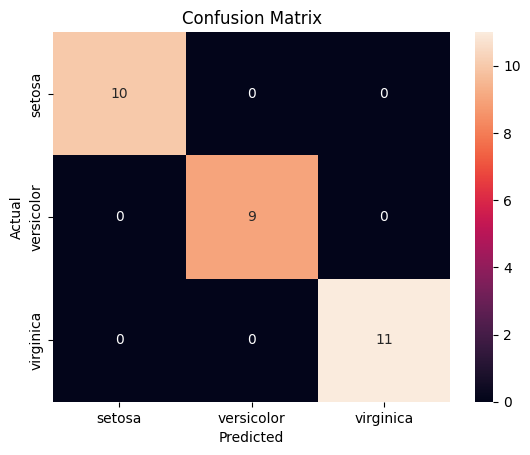

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
explainer = LimeTabularExplainer(
    training_data=X_train,
    feature_names=feature_names,
    class_names=class_names,
    mode='classification'
)

num_samples_per_class = 5

# Initialize importance storage
class_importance = {
    i: np.zeros(len(feature_names))
    for i in range(len(class_names))
}

# Loop over each class
for class_id in range(len(class_names)):
    count = 0

    # Loop over test samples
    for i in range(len(X_test)):
        if y_test[i] == class_id:

            exp = explainer.explain_instance(
                X_test[i],
                model.predict_proba
            )


            for feature, weight in exp.as_list():
                for idx, fname in enumerate(feature_names):
                    if fname in feature:
                        class_importance[class_id][idx] += weight
                        break

            count += 1

            # Stop after N samples per class
            if count >= num_samples_per_class:
                break

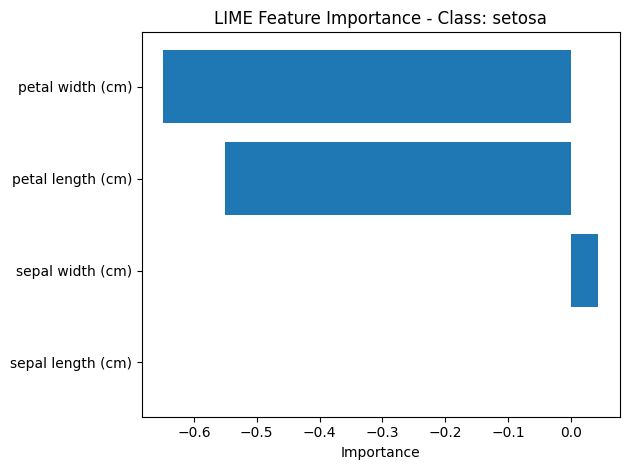

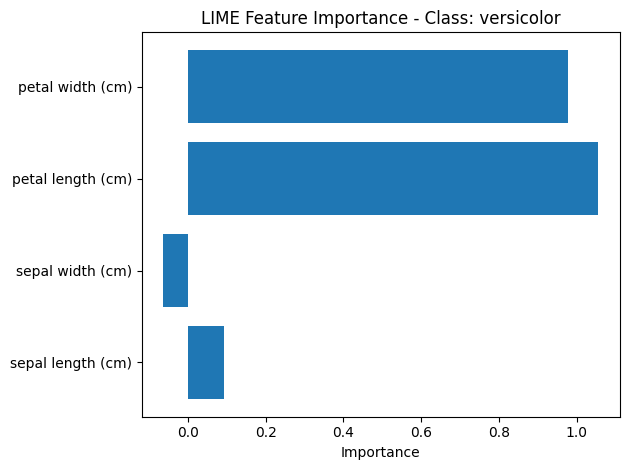

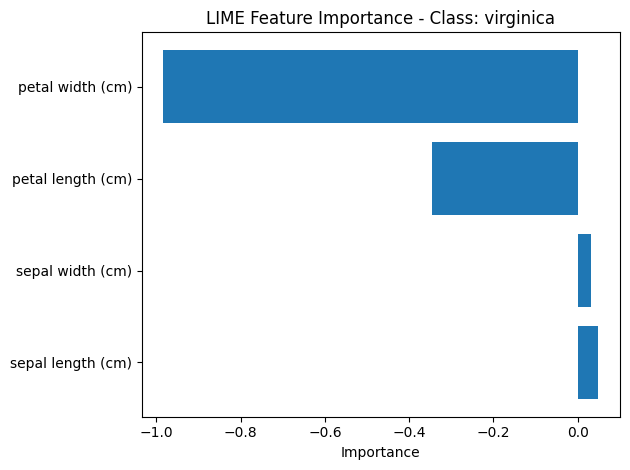

In [ ]:
for class_id, importance in class_importance.items():

    plt.figure()
    plt.barh(feature_names, importance)

    plt.xlabel("Importance")
    plt.title(f"LIME Feature Importance - Class: {class_names[class_id]}")

    plt.tight_layout()
    plt.show()